In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [2]:
#Device + Hyperparameters
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Hyperparameters
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 15
INPUT_SIZE = 28 * 28
NUM_CLASSES = 10

Using device: cuda


In [3]:
#Data Preprocessing + Load Dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print("Dataset loaded successfully")

100%|██████████| 26.4M/26.4M [00:00<00:00, 111MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.35MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 59.6MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.4MB/s]


Dataset loaded successfully


In [4]:
#Split Data + DataLoaders
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)

print("Data loaders ready")

Data loaders ready


In [8]:
# Build MLP Model
class MLP(nn.Module):
    def __init__(self, activation='relu'):
        super().__init__()

       # اactivation function
        if activation == 'relu':
            act = nn.ReLU()
        elif activation == 'sigmoid':
            act = nn.Sigmoid()
        else:
            raise ValueError("Choose relu or sigmoid")

        # Model architecture
        self.model = nn.Sequential(
            nn.Flatten(),

            nn.Linear(INPUT_SIZE, 128),
            nn.BatchNorm1d(128),
            act,
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            act,
            nn.Dropout(0.2),

            nn.Linear(64, NUM_CLASSES)
        )

    def forward(self, x):
        return self.model(x)

print("Model class created")

Model class created


In [9]:
def train_model(activation_name):

    print(f"\nTraining with {activation_name} activation")

    model = MLP(activation=activation_name).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(EPOCHS):

        # =========================
        # Training
        # =========================
        model.train()
        running_loss = 0

        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            #  Accuracy calculation
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        avg_train_loss = running_loss / len(train_loader)
        train_acc = correct / total

        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)

        # =========================
        # Validation
        # =========================
        model.eval()
        val_loss = 0
        preds = []
        truths = []

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                preds.extend(predicted.cpu().numpy())
                truths.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(truths, preds)

        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(
            f"Epoch {epoch+1}/{EPOCHS} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    return model, train_losses, train_accuracies, val_losses, val_accuracies

In [11]:
#Experiment 1 (ReLU)
relu_model, relu_train_loss, relu_train_acc, relu_val_loss, relu_val_acc = train_model('relu')


Training with relu activation
Epoch 1/15 | Train Loss: 0.6036 | Train Acc: 0.8022 | Val Loss: 0.3960 | Val Acc: 0.8554
Epoch 2/15 | Train Loss: 0.4410 | Train Acc: 0.8432 | Val Loss: 0.3561 | Val Acc: 0.8669
Epoch 3/15 | Train Loss: 0.4068 | Train Acc: 0.8541 | Val Loss: 0.3431 | Val Acc: 0.8708
Epoch 4/15 | Train Loss: 0.3837 | Train Acc: 0.8617 | Val Loss: 0.3536 | Val Acc: 0.8653
Epoch 5/15 | Train Loss: 0.3644 | Train Acc: 0.8692 | Val Loss: 0.3202 | Val Acc: 0.8843
Epoch 6/15 | Train Loss: 0.3528 | Train Acc: 0.8712 | Val Loss: 0.3194 | Val Acc: 0.8842
Epoch 7/15 | Train Loss: 0.3389 | Train Acc: 0.8753 | Val Loss: 0.3143 | Val Acc: 0.8839
Epoch 8/15 | Train Loss: 0.3295 | Train Acc: 0.8791 | Val Loss: 0.3063 | Val Acc: 0.8870
Epoch 9/15 | Train Loss: 0.3220 | Train Acc: 0.8823 | Val Loss: 0.3006 | Val Acc: 0.8898
Epoch 10/15 | Train Loss: 0.3162 | Train Acc: 0.8851 | Val Loss: 0.3073 | Val Acc: 0.8858
Epoch 11/15 | Train Loss: 0.3038 | Train Acc: 0.8891 | Val Loss: 0.2974 | Val 

In [12]:
#Experiment 2 (Sigmoid)
sig_model, sig_train_loss, sig_train_acc, sig_val_loss, sig_val_acc = train_model('sigmoid')


Training with sigmoid activation
Epoch 1/15 | Train Loss: 0.9873 | Train Acc: 0.7455 | Val Loss: 0.5228 | Val Acc: 0.8301
Epoch 2/15 | Train Loss: 0.5663 | Train Acc: 0.8103 | Val Loss: 0.4462 | Val Acc: 0.8429
Epoch 3/15 | Train Loss: 0.5030 | Train Acc: 0.8263 | Val Loss: 0.4161 | Val Acc: 0.8548
Epoch 4/15 | Train Loss: 0.4716 | Train Acc: 0.8354 | Val Loss: 0.3996 | Val Acc: 0.8564
Epoch 5/15 | Train Loss: 0.4513 | Train Acc: 0.8402 | Val Loss: 0.3795 | Val Acc: 0.8652
Epoch 6/15 | Train Loss: 0.4250 | Train Acc: 0.8486 | Val Loss: 0.3726 | Val Acc: 0.8670
Epoch 7/15 | Train Loss: 0.4150 | Train Acc: 0.8525 | Val Loss: 0.3752 | Val Acc: 0.8611
Epoch 8/15 | Train Loss: 0.3955 | Train Acc: 0.8581 | Val Loss: 0.3534 | Val Acc: 0.8728
Epoch 9/15 | Train Loss: 0.3894 | Train Acc: 0.8611 | Val Loss: 0.3532 | Val Acc: 0.8738
Epoch 10/15 | Train Loss: 0.3764 | Train Acc: 0.8636 | Val Loss: 0.3558 | Val Acc: 0.8698
Epoch 11/15 | Train Loss: 0.3709 | Train Acc: 0.8665 | Val Loss: 0.3457 | V

In [13]:
#Evaluation Function
def evaluate(model):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    test_loss = 0
    preds = []
    truths = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            preds.extend(predicted.cpu().numpy())
            truths.extend(labels.cpu().numpy())

    avg_loss = test_loss / len(test_loader)
    acc = accuracy_score(truths, preds)

    return avg_loss, acc

In [14]:
#Final Results
relu_test_loss, relu_test_acc = evaluate(relu_model)
sig_test_loss, sig_test_acc = evaluate(sig_model)

print("\n========== FINAL RESULTS ==========")
print(f"ReLU    : Test Loss: {relu_test_loss:.4f} | Test Accuracy: {relu_test_acc:.4f}")
print(f"Sigmoid : Test Loss: {sig_test_loss:.4f} | Test Accuracy: {sig_test_acc:.4f}")


========== FINAL RESULTS ==========
ReLU    : Test Loss: 0.3179 | Test Accuracy: 0.8849
Sigmoid : Test Loss: 0.3507 | Test Accuracy: 0.8733


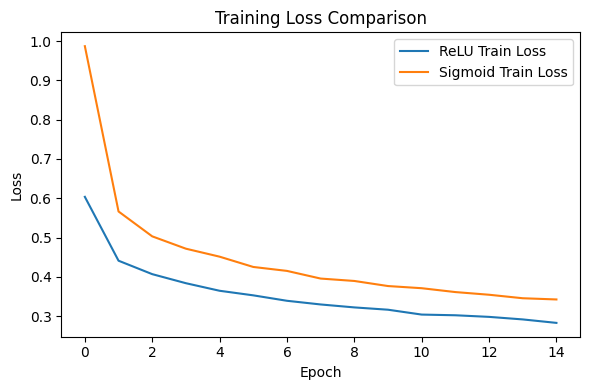

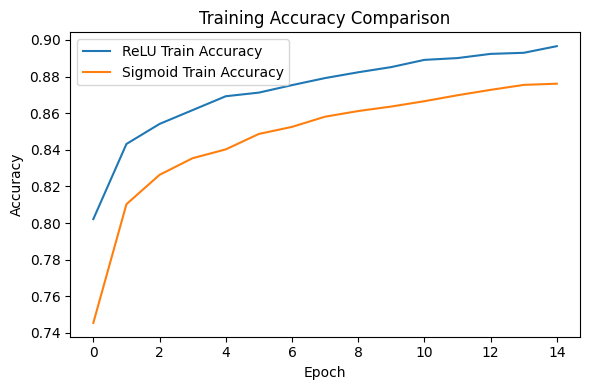

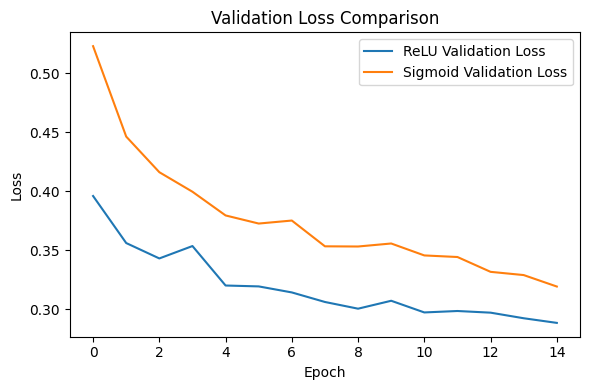

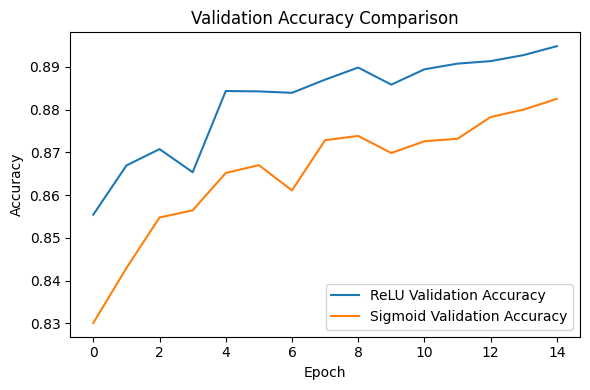

Project completed successfully


In [16]:
# =========================
# 1) TRAIN LOSS
# =========================
plt.figure(figsize=(6,4))

plt.plot(relu_train_loss, label='ReLU Train Loss')
plt.plot(sig_train_loss, label='Sigmoid Train Loss')

plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("train_loss_comparison.png")
plt.show()


# =========================
# 2) TRAIN ACCURACY
# =========================
plt.figure(figsize=(6,4))

plt.plot(relu_train_acc, label='ReLU Train Accuracy')
plt.plot(sig_train_acc, label='Sigmoid Train Accuracy')

plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig("train_accuracy_comparison.png")
plt.show()


# =========================
# 3) VALIDATION LOSS
# =========================
plt.figure(figsize=(6,4))

plt.plot(relu_val_loss, label='ReLU Validation Loss')
plt.plot(sig_val_loss, label='Sigmoid Validation Loss')

plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("val_loss_comparison.png")
plt.show()


# =========================
# 4) VALIDATION ACCURACY
# =========================
plt.figure(figsize=(6,4))

plt.plot(relu_val_acc, label='ReLU Validation Accuracy')
plt.plot(sig_val_acc, label='Sigmoid Validation Accuracy')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig("val_accuracy_comparison.png")
plt.show()


print("Project completed successfully")